# EDA — Dataset sintético embarazo (solo gráficos)

Visualización exploratoria del dataset generado. Sin tablas de resumen.

**Fuentes:** `../data/datos_embarazo_sintetico.csv`, `../data/metadatos_ground_truth.csv`, `../data/missingness_log.csv`

In [12]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams["figure.dpi"] = 110

DATA_DIR = Path("../data")

df = pd.read_csv(DATA_DIR / "datos_embarazo_sintetico.csv")
meta = pd.read_csv(DATA_DIR / "metadatos_ground_truth.csv")
log_miss = pd.read_csv(DATA_DIR / "missingness_log.csv")

df_full = df.merge(meta, on="paciente_id", how="left")

CLUSTER_LABELS = {
    0: "C0 Bajo riesgo",
    1: "C1 Metabólico",
    2: "C2 Hipertensivo",
    3: "C3 Bajo peso",
    4: "C4 Alto riesgo",
    5: "C5 Residual",
}
df_full["cluster_nombre"] = df_full["cluster_verdadero"].map(CLUSTER_LABELS)

CONTINUOUS = [
    "edad_anios", "imc_pregestacional", "semanas_gestacion",
    "peso_kg", "talla_cm", "ganancia_peso_kg",
    "presion_sistolica", "presion_diastolica", "frecuencia_cardiaca",
]
KEY_PAIRS = [
    ("imc_pregestacional", "ganancia_peso_kg"),
    ("semanas_gestacion", "ganancia_peso_kg"),
    ("presion_sistolica", "presion_diastolica"),
    ("edad_anios", "imc_pregestacional"),
    ("peso_kg", "imc_pregestacional"),
    ("semanas_gestacion", "peso_kg"),
]

## 1. Distribuciones univariadas (variables continuas)

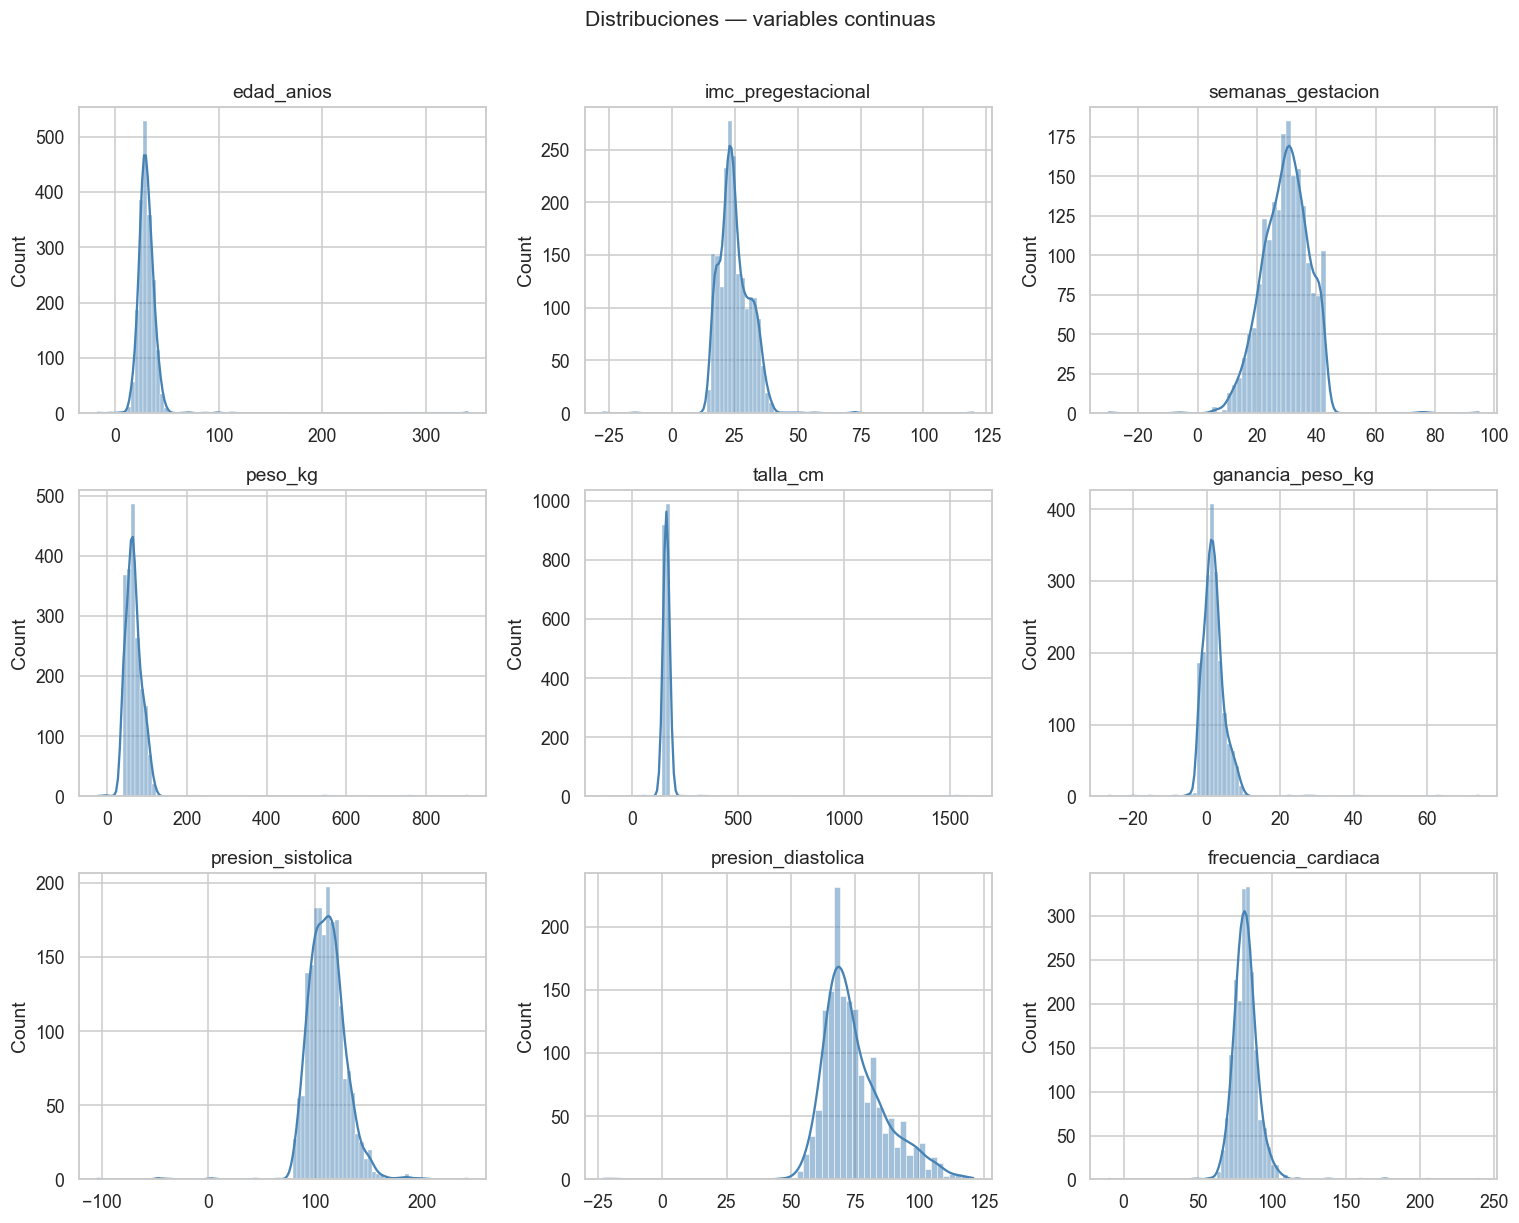

In [13]:
fig, axes = plt.subplots(3, 3, figsize=(14, 11))
axes = axes.flatten()

for ax, col in zip(axes, CONTINUOUS):
    sns.histplot(df[col].dropna(), kde=True, ax=ax, color="steelblue", edgecolor="white")
    ax.set_title(col)
    ax.set_xlabel("")

fig.suptitle("Distribuciones — variables continuas", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 2. Boxplots por cluster verdadero

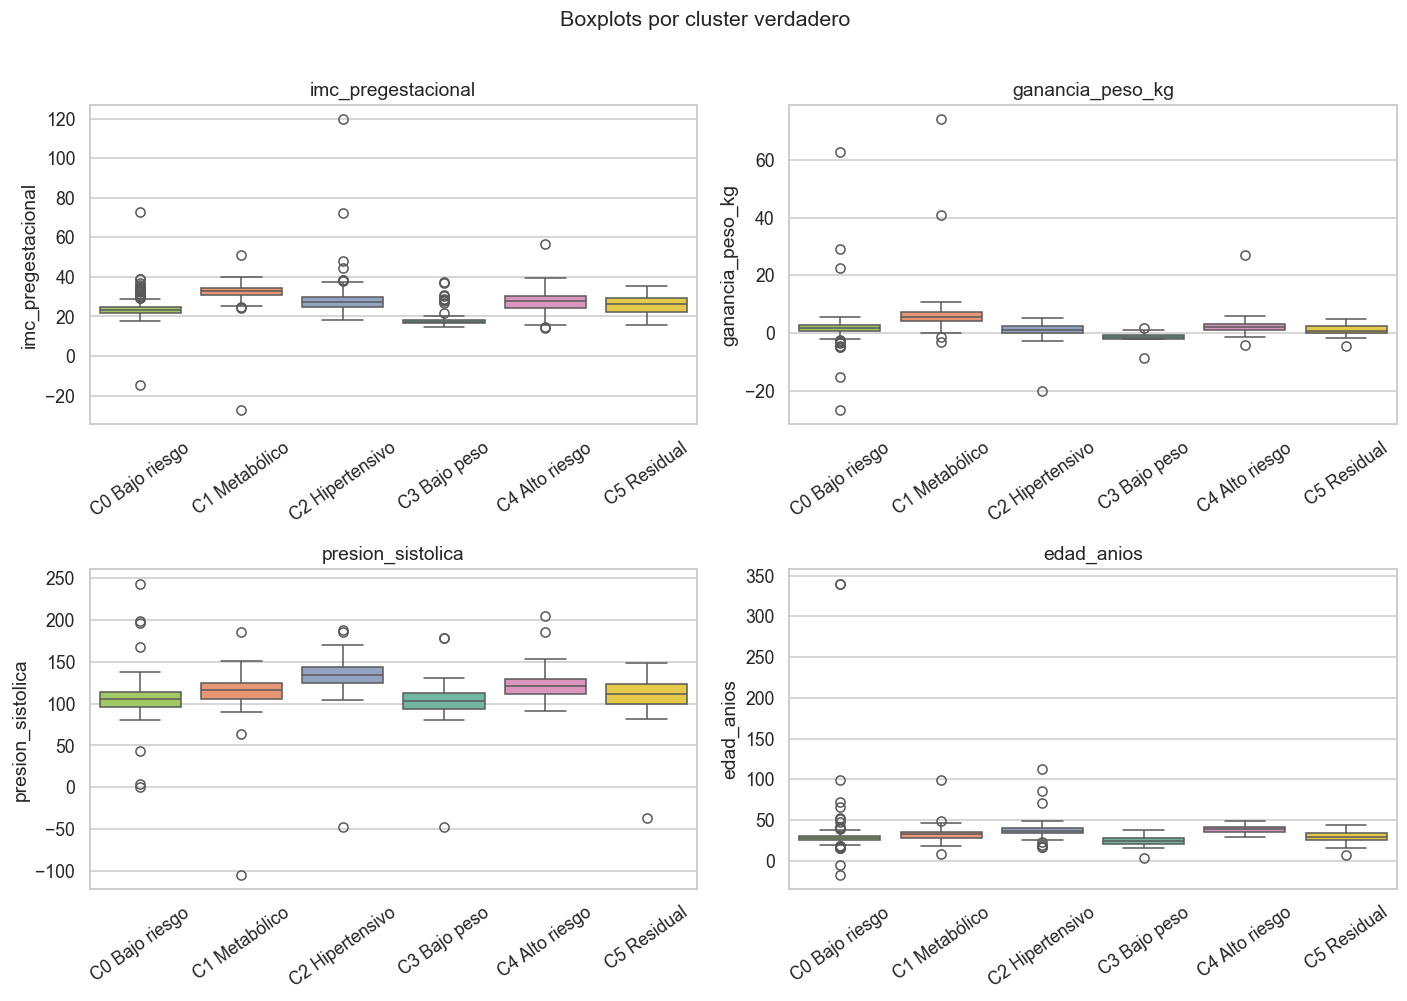

In [14]:
vars_box = ["imc_pregestacional", "ganancia_peso_kg", "presion_sistolica", "edad_anios"]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

orden = [CLUSTER_LABELS[i] for i in sorted(CLUSTER_LABELS)]
for ax, col in zip(axes, vars_box):
    sns.boxplot(
        data=df_full, x="cluster_nombre", y=col, order=orden,
        ax=ax, hue="cluster_nombre", legend=False, palette="Set2",
    )
    ax.set_title(col)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=35)

fig.suptitle("Boxplots por cluster verdadero", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 3. Violin plots — signos vitales por trimestre

C:\Users\MAXIMILIANO\AppData\Local\Temp\ipykernel_16212\1558842599.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="trimestre", y=col, ax=ax, palette="Blues", inner="quartile")
C:\Users\MAXIMILIANO\AppData\Local\Temp\ipykernel_16212\1558842599.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="trimestre", y=col, ax=ax, palette="Blues", inner="quartile")
C:\Users\MAXIMILIANO\AppData\Local\Temp\ipykernel_16212\1558842599.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="trimestre", y=col, ax=a

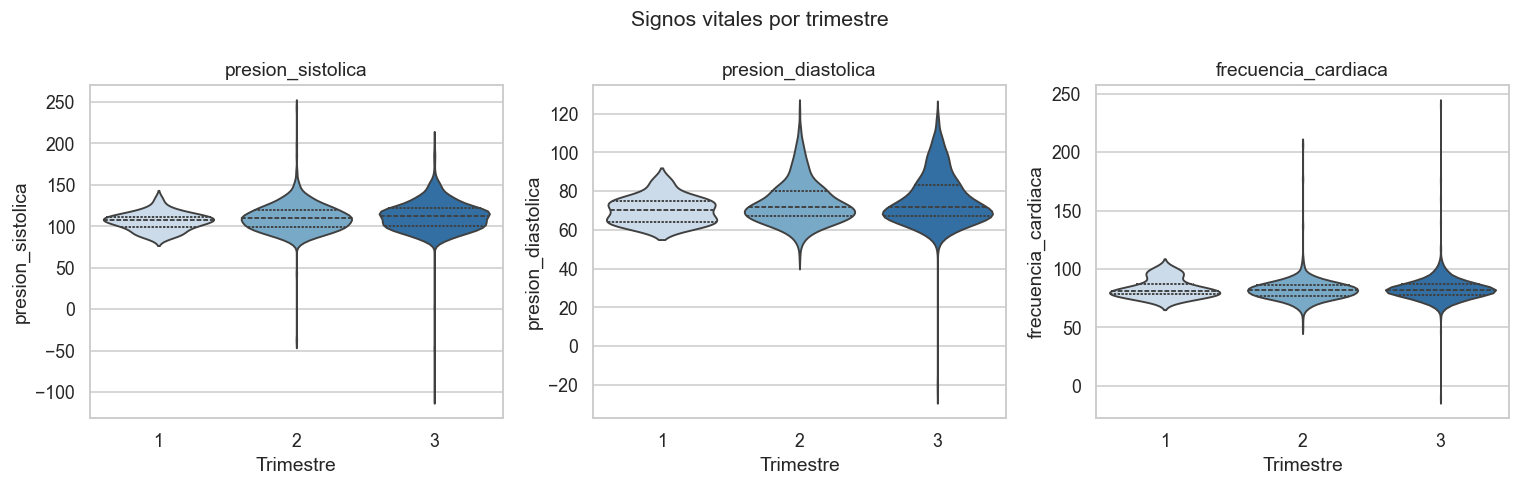

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
vitales = ["presion_sistolica", "presion_diastolica", "frecuencia_cardiaca"]

for ax, col in zip(axes, vitales):
    sns.violinplot(data=df, x="trimestre", y=col, ax=ax, palette="Blues", inner="quartile")
    ax.set_title(col)
    ax.set_xlabel("Trimestre")

fig.suptitle("Signos vitales por trimestre", fontsize=14)
plt.tight_layout()
plt.show()

## 4. Variables categóricas y binarias

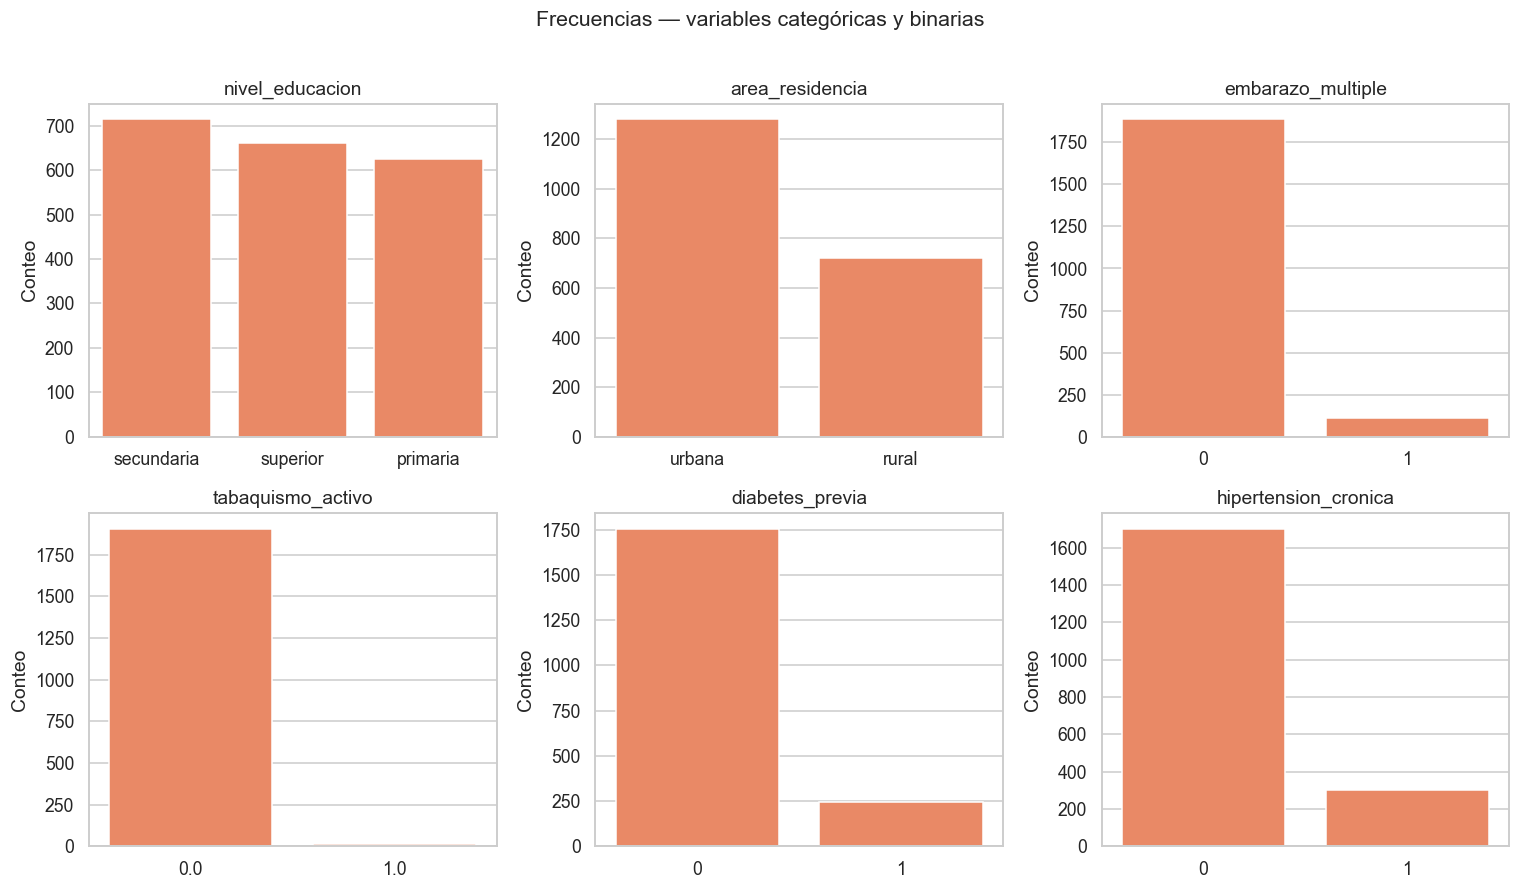

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

cat_cols = [
    "nivel_educacion", "area_residencia",
    "embarazo_multiple", "tabaquismo_activo",
    "diabetes_previa", "hipertension_cronica",
]

for ax, col in zip(axes, cat_cols):
    counts = df[col].value_counts(dropna=False)
    sns.barplot(x=counts.index.astype(str), y=counts.values, ax=ax, color="coral")
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("Conteo")

fig.suptitle("Frecuencias — variables categóricas y binarias", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 5. Distribución de clusters y outliers

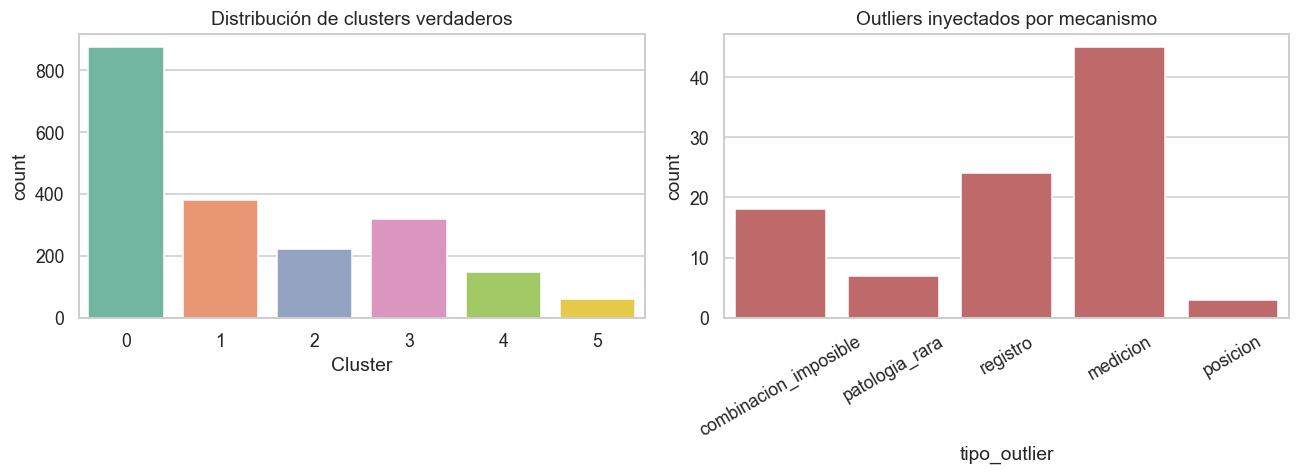

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.countplot(
    data=meta, x="cluster_verdadero", ax=axes[0],
    hue="cluster_verdadero", palette="Set2", legend=False,
)
axes[0].set_title("Distribución de clusters verdaderos")
axes[0].set_xlabel("Cluster")

out = meta[meta["es_outlier"] == 1]
if len(out):
    sns.countplot(data=out, x="tipo_outlier", ax=axes[1], color="indianred")
    axes[1].tick_params(axis="x", rotation=30)
axes[1].set_title("Outliers inyectados por mecanismo")

plt.tight_layout()
plt.show()

## 6. Missingness

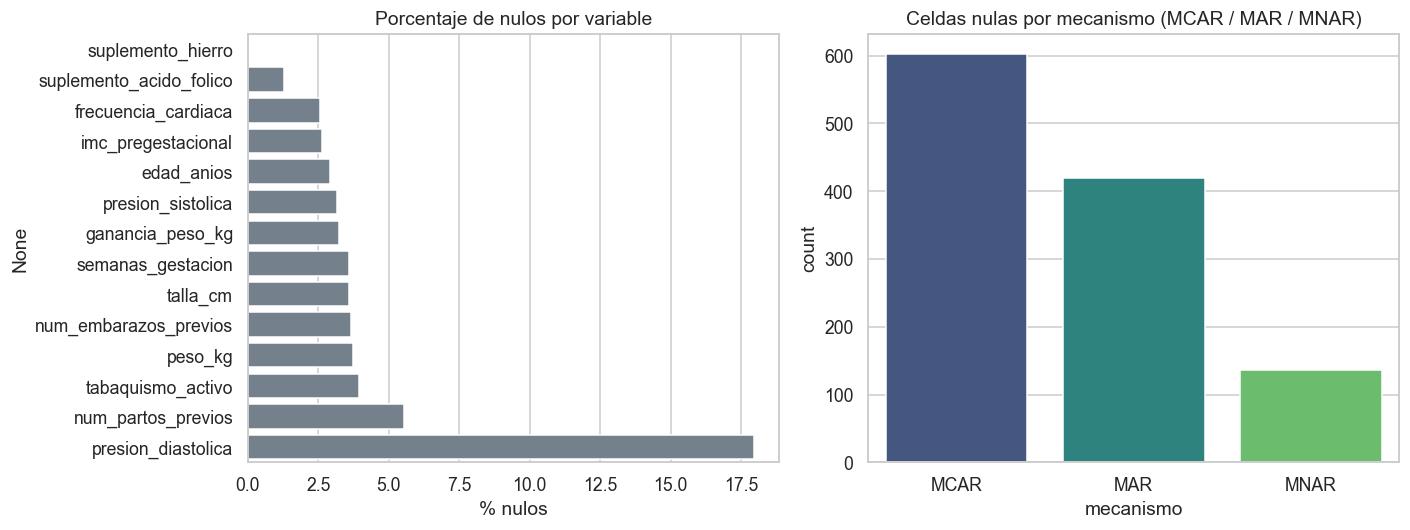

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

miss_pct = df.isna().mean().sort_values(ascending=True) * 100
miss_pct = miss_pct[miss_pct > 0]
sns.barplot(x=miss_pct.values, y=miss_pct.index, ax=axes[0], color="slategray")
axes[0].set_title("Porcentaje de nulos por variable")
axes[0].set_xlabel("% nulos")

sns.countplot(data=log_miss, x="mecanismo", hue="mecanismo", ax=axes[1], palette="viridis", legend=False)
axes[1].set_title("Celdas nulas por mecanismo (MCAR / MAR / MNAR)")

plt.tight_layout()
plt.show()

## 7. Matriz de correlación

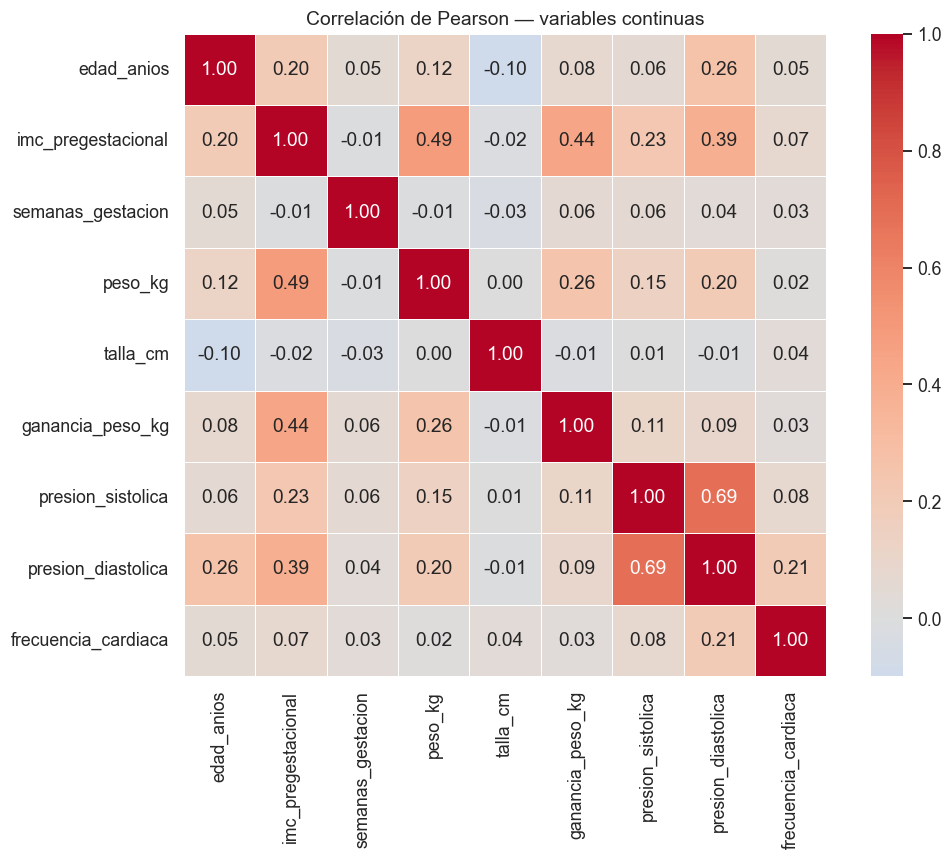

In [19]:
corr = df[CONTINUOUS].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr, annot=True, fmt=".2f", cmap="coolwarm",
    center=0, square=True, linewidths=0.5, ax=ax,
)
ax.set_title("Correlación de Pearson — variables continuas")
plt.tight_layout()
plt.show()

## 8. Scatter plots — relaciones clínicas clave

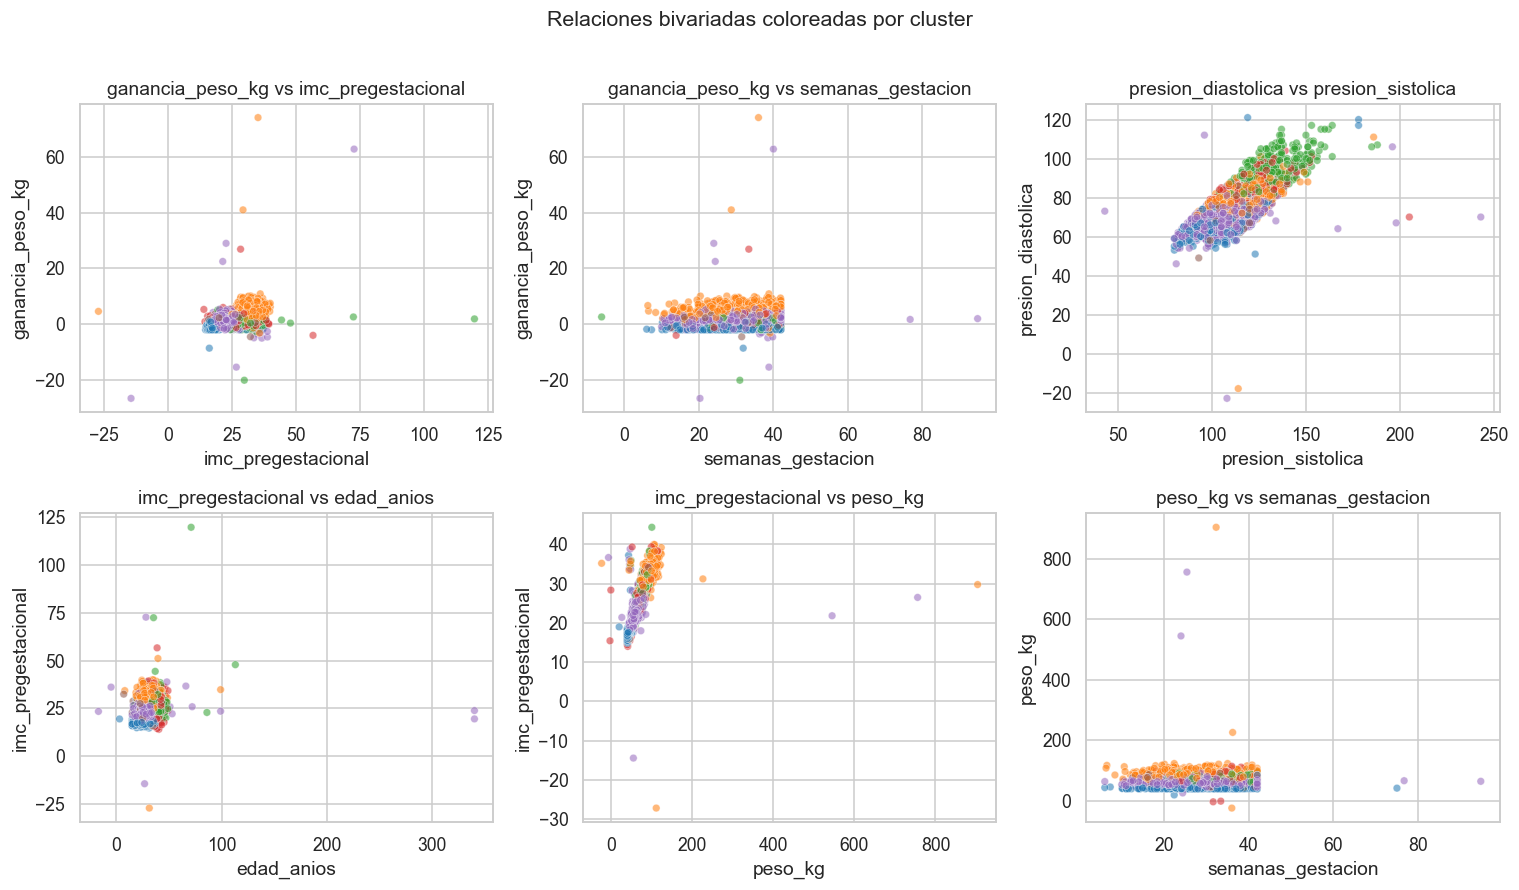

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for ax, (x, y) in zip(axes, KEY_PAIRS):
    sns.scatterplot(
        data=df_full, x=x, y=y, hue="cluster_nombre",
        alpha=0.55, s=25, ax=ax, palette="tab10", legend=False,
    )
    ax.set_title(f"{y} vs {x}")

fig.suptitle("Relaciones bivariadas coloreadas por cluster", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 9. Pairplot — subconjunto de variables principales

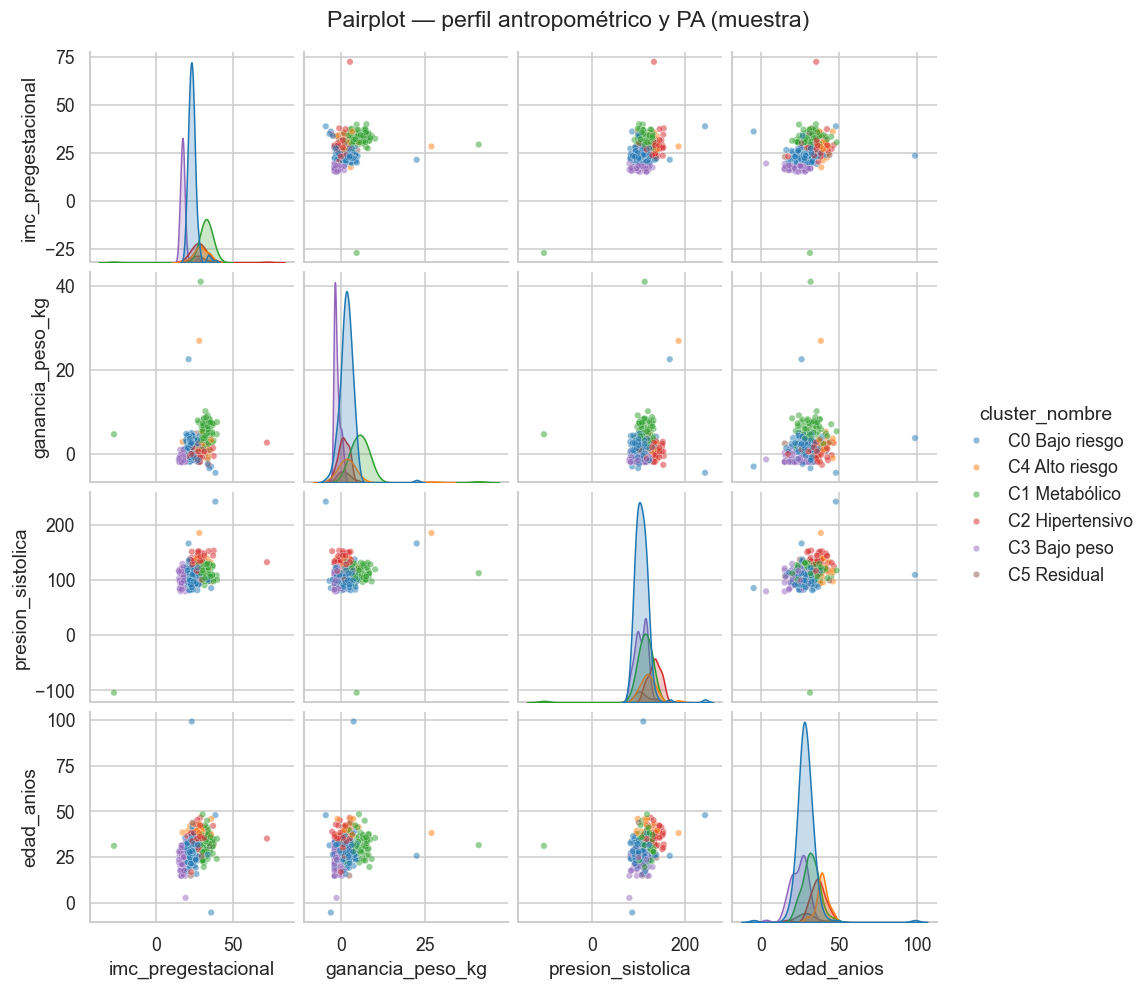

In [21]:
subset = df_full.sample(min(400, len(df_full)), random_state=42)
pair_vars = ["imc_pregestacional", "ganancia_peso_kg", "presion_sistolica", "edad_anios"]

g = sns.pairplot(
    subset, vars=pair_vars, hue="cluster_nombre",
    palette="tab10", plot_kws={"alpha": 0.5, "s": 18},
    diag_kind="kde", corner=False, height=2.2,
)
g.figure.suptitle("Pairplot — perfil antropométrico y PA (muestra)", y=1.02)
plt.show()

## 10. Comorbilidades y suplementos por cluster

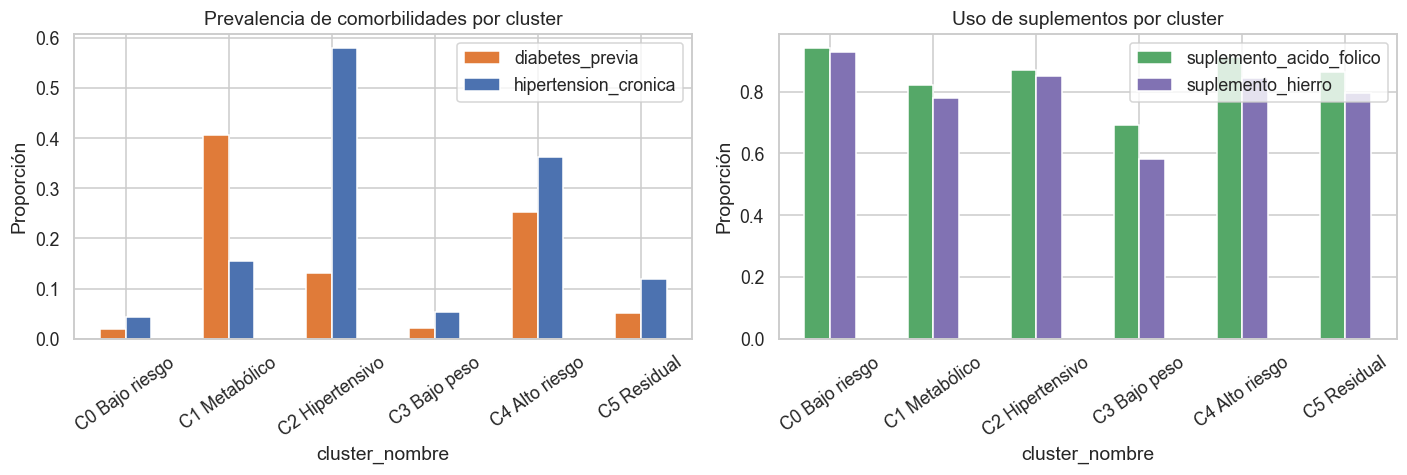

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

prop = df_full.groupby("cluster_nombre")[["diabetes_previa", "hipertension_cronica"]].mean()
prop.plot(kind="bar", ax=axes[0], color=["#e07b39", "#4c72b0"])
axes[0].set_title("Prevalencia de comorbilidades por cluster")
axes[0].set_ylabel("Proporción")
axes[0].tick_params(axis="x", rotation=35)
axes[0].legend(title="")

prop_sup = df_full.groupby("cluster_nombre")[["suplemento_acido_folico", "suplemento_hierro"]].mean()
prop_sup.plot(kind="bar", ax=axes[1], color=["#55a868", "#8172b3"])
axes[1].set_title("Uso de suplementos por cluster")
axes[1].set_ylabel("Proporción")
axes[1].tick_params(axis="x", rotation=35)
axes[1].legend(title="")

plt.tight_layout()
plt.show()

## 11. Outliers vs variables clave

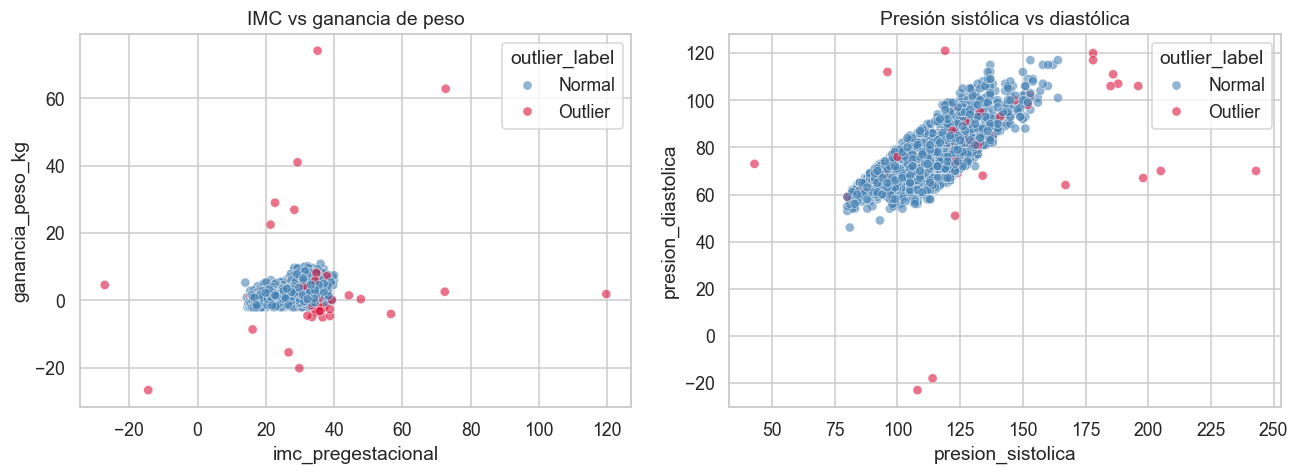

In [23]:
df_full["outlier_label"] = df_full["es_outlier"].map({0: "Normal", 1: "Outlier"})

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.scatterplot(
    data=df_full, x="imc_pregestacional", y="ganancia_peso_kg",
    hue="outlier_label", alpha=0.6, ax=axes[0], palette={"Normal": "steelblue", "Outlier": "crimson"},
)
axes[0].set_title("IMC vs ganancia de peso")

sns.scatterplot(
    data=df_full, x="presion_sistolica", y="presion_diastolica",
    hue="outlier_label", alpha=0.6, ax=axes[1], palette={"Normal": "steelblue", "Outlier": "crimson"},
)
axes[1].set_title("Presión sistólica vs diastólica")

plt.tight_layout()
plt.show()

## 12. Stripplot — IMC por nivel educativo y área

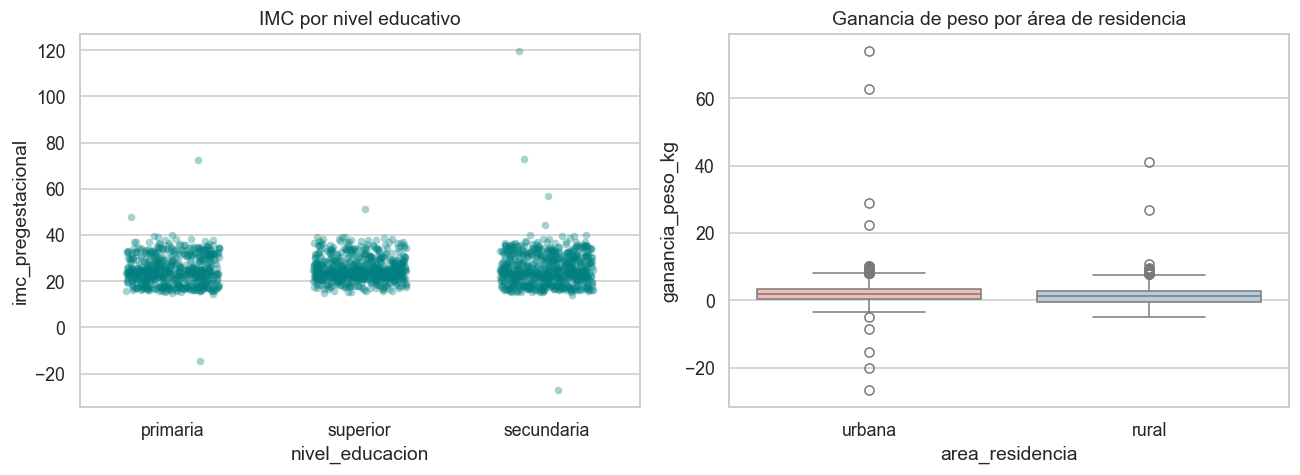

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.stripplot(
    data=df, x="nivel_educacion", y="imc_pregestacional",
    ax=axes[0], alpha=0.35, jitter=0.25, color="teal",
)
axes[0].set_title("IMC por nivel educativo")

sns.boxplot(
    data=df, x="area_residencia", y="ganancia_peso_kg",
    ax=axes[1], palette="Pastel1", hue="area_residencia", legend=False,
)
axes[1].set_title("Ganancia de peso por área de residencia")

plt.tight_layout()
plt.show()